In [64]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.7.0+cu126
CUDA Available: True
GPU: NVIDIA GeForce RTX 3080


检查路径

In [65]:
import os
print(os.listdir('tensorForTesting/processed'))

['y_train.npy', 'X_val.npy', 'scaler_b.pkl', 'scaler_a.pkl', 'X_train.npy', 'scaler_c.pkl', 'y_test.npy', 'X_test.npy', 'scaler_X.pkl', 'y_val.npy']


导入其余包

In [66]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from torchmetrics import MeanAbsoluteError
from viewdata import load_data
import numpy as np
print(f"PyTorch Version: {torch.__version__}")
print(f"Pyro Version: {pyro.__version__}")

PyTorch Version: 2.7.0+cu126
Pyro Version: 1.9.1


定义贝叶斯 CNN 模型

In [67]:
class BayesianCNN(PyroModule):
    def __init__(self):
        super(BayesianCNN, self).__init__()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 初始化卷积层，保留 nn.Module 的参数
        self.conv1 = PyroModule[nn.Conv2d](1, 16, kernel_size=3, padding=1).to(device)
        self.conv1.weight = PyroSample(
            dist.Normal(torch.zeros([16, 1, 3, 3], device=device), 
                        0.01 * torch.ones([16, 1, 3, 3], device=device)).to_event(4))
        self.conv1.bias = PyroSample(
            dist.Normal(torch.zeros([16], device=device), 
                        0.01 * torch.ones([16], device=device)).to_event(1))
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = PyroModule[nn.Conv2d](16, 32, kernel_size=3, padding=1).to(device)
        self.conv2.weight = PyroSample(
            dist.Normal(torch.zeros([32, 16, 3, 3], device=device), 
                        0.01 * torch.ones([32, 16, 3, 3], device=device)).to_event(4))
        self.conv2.bias = PyroSample(
            dist.Normal(torch.zeros([32], device=device), 
                        0.01 * torch.ones([32], device=device)).to_event(1))
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        
        self.flatten = nn.Flatten()
        
        self.fc1 = PyroModule[nn.Linear](19 * 5 * 32, 64).to(device)
        self.fc1.weight = PyroSample(
            dist.Normal(torch.zeros([64, 19 * 5 * 32], device=device), 
                        0.01 * torch.ones([64, 19 * 5 * 32], device=device)).to_event(2))
        self.fc1.bias = PyroSample(
            dist.Normal(torch.zeros([64], device=device), 
                        0.01 * torch.ones([64], device=device)).to_event(1))
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
        self.fc2 = PyroModule[nn.Linear](64, 3).to(device)
        self.fc2.weight = PyroSample(
            dist.Normal(torch.zeros([3, 64], device=device), 
                        0.01 * torch.ones([3, 64], device=device)).to_event(2))
        self.fc2.bias = PyroSample(
            dist.Normal(torch.zeros([3], device=device), 
                        0.01 * torch.ones([3], device=device)).to_event(1))
    
    def forward(self, x, y=None):
        print(f"Input shape: {x.shape}")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        x = x.to(device)
        
        # 检查权重和偏置
        conv1_weight = self.conv1.weight
        conv1_bias = self.conv1.bias
        print(f"conv1.weight: mean={conv1_weight.mean().item()}, std={conv1_weight.std().item()}, has_nan={torch.isnan(conv1_weight).any().item()}, has_inf={torch.isinf(conv1_weight).any().item()}")
        print(f"conv1.bias: mean={conv1_bias.mean().item()}, std={conv1_bias.std().item()}, has_nan={torch.isnan(conv1_bias).any().item()}, has_inf={torch.isinf(conv1_bias).any().item()}")
        
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        with pyro.plate('data', x.shape[0]):
            obs_dist = dist.Normal(x, 0.1).to_event(1)
            pyro.sample('obs', obs_dist, obs=y)
        return x
    
    def guide(self, x, y=None):
        device = x.device
        # 初始化变分参数，确保 sigma 为正
        conv1_w_mu = pyro.param('conv1_w_mu', torch.randn([16, 1, 3, 3], device=device), constraint=dist.constraints.real)
        conv1_w_sigma = pyro.param('conv1_w_sigma', torch.abs(torch.randn([16, 1, 3, 3], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.conv1.weight = PyroSample(
            dist.Normal(conv1_w_mu, torch.nn.functional.softplus(conv1_w_sigma)).to_event(4))
        conv1_b_mu = pyro.param('conv1_b_mu', torch.randn([16], device=device), constraint=dist.constraints.real)
        conv1_b_sigma = pyro.param('conv1_b_sigma', torch.abs(torch.randn([16], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.conv1.bias = PyroSample(
            dist.Normal(conv1_b_mu, torch.nn.functional.softplus(conv1_b_sigma)).to_event(1))
        
        conv2_w_mu = pyro.param('conv2_w_mu', torch.randn([32, 16, 3, 3], device=device), constraint=dist.constraints.real)
        conv2_w_sigma = pyro.param('conv2_w_sigma', torch.abs(torch.randn([32, 16, 3, 3], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.conv2.weight = PyroSample(
            dist.Normal(conv2_w_mu, torch.nn.functional.softplus(conv2_w_sigma)).to_event(4))
        conv2_b_mu = pyro.param('conv2_b_mu', torch.randn([32], device=device), constraint=dist.constraints.real)
        conv2_b_sigma = pyro.param('conv2_b_sigma', torch.abs(torch.randn([32], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.conv2.bias = PyroSample(
            dist.Normal(conv2_b_mu, torch.nn.functional.softplus(conv2_b_sigma)).to_event(1))
        
        fc1_w_mu = pyro.param('fc1_w_mu', torch.randn([64, 19 * 5 * 32], device=device), constraint=dist.constraints.real)
        fc1_w_sigma = pyro.param('fc1_w_sigma', torch.abs(torch.randn([64, 19 * 5 * 32], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.fc1.weight = PyroSample(
            dist.Normal(fc1_w_mu, torch.nn.functional.softplus(fc1_w_sigma)).to_event(2))
        fc1_b_mu = pyro.param('fc1_b_mu', torch.randn([64], device=device), constraint=dist.constraints.real)
        fc1_b_sigma = pyro.param('fc1_b_sigma', torch.abs(torch.randn([64], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.fc1.bias = PyroSample(
            dist.Normal(fc1_b_mu, torch.nn.functional.softplus(fc1_b_sigma)).to_event(1))
        
        fc2_w_mu = pyro.param('fc2_w_mu', torch.randn([3, 64], device=device), constraint=dist.constraints.real)
        fc2_w_sigma = pyro.param('fc2_w_sigma', torch.abs(torch.randn([3, 64], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.fc2.weight = PyroSample(
            dist.Normal(fc2_w_mu, torch.nn.functional.softplus(fc2_w_sigma)).to_event(2))
        fc2_b_mu = pyro.param('fc2_b_mu', torch.randn([3], device=device), constraint=dist.constraints.real)
        fc2_b_sigma = pyro.param('fc2_b_sigma', torch.abs(torch.randn([3], device=device)) + 1e-2, constraint=dist.constraints.positive)
        self.fc2.bias = PyroSample(
            dist.Normal(fc2_b_mu, torch.nn.functional.softplus(fc2_b_sigma)).to_event(1))
        
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

定义训练函数

In [68]:
def train_bnn(model, train_loader, valid_loader, epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    pyro.clear_param_store()
    optimizer = pyro.optim.Adam({'lr': 0.0001})
    svi = SVI(model, model.guide, optimizer, loss=Trace_ELBO(num_particles=10))
    mae = MeanAbsoluteError().to(device)

    print(f"Initial Pyro parameters: {pyro.get_param_store().keys()}")

    best_valid_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_loss, train_mae = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            print(f"Input x shape: {x.shape}, y shape: {y.shape}")
            print(f"Input x device: {x.device}")
            loss = svi.step(x, y)
            print(f"Pyro parameters after step: {pyro.get_param_store().keys()}")
            with torch.no_grad():
                output = model(x)
                train_mae += mae(output, y).item()
            train_loss += loss / x.shape[0]
        train_loss /= len(train_loader)
        train_mae /= len(train_loader)

        model.eval()
        valid_loss, valid_mae = 0, 0
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                loss = svi.evaluate_loss(x, y)
                output = model(x)
                valid_loss += loss / x.shape[0]
                valid_mae += mae(output, y).item()
        valid_loss /= len(valid_loader)
        valid_mae /= len(valid_loader)

        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Valid Loss: {valid_loss:.4f}, Valid MAE: {valid_mae:.4f}')

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_bnn_model.pt')

    return model

定义测试函数（包括不确定性估计）

In [69]:
def test_bnn(model, test_loader, num_samples=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    mae = MeanAbsoluteError().to(device)
    test_loss, test_mae = 0, 0
    predictions, trues = [], []

    # 使用 Pyro 的预测性采样
    predictive = pyro.infer.Predictive(model, guide=model.guide, num_samples=num_samples)
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = predictive(x)['obs']
            mean_preds = preds.mean(dim=0)  # 平均预测
            test_loss += nn.MSELoss()(mean_preds, y).item()
            test_mae += mae(mean_preds, y).item()
            predictions.append(mean_preds.cpu().numpy())
            trues.append(y.cpu().numpy())

    test_loss /= len(test_loader)
    test_mae /= len(test_loader)
    predictions = np.concatenate(predictions, axis=0)
    trues = np.concatenate(trues, axis=0)
    print(f'Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}')
    return test_loss, test_mae, predictions, trues

检查数据和标签是否正常，存在空值需要调整为0

In [29]:
import numpy as np

def check_data(file_path):
    data = np.load(file_path)
    print(f"{file_path}: shape={data.shape}, has_nan={np.any(np.isnan(data))}, has_inf={np.any(np.isinf(data))}")

files = [
    'tensorForTesting/processed/X_train.npy',
    'tensorForTesting/processed/y_train.npy',
    'tensorForTesting/processed/X_val.npy',
    'tensorForTesting/processed/y_val.npy',
    'tensorForTesting/processed/X_test.npy',
    'tensorForTesting/processed/y_test.npy'
]
for f in files:
    check_data(f)

tensorForTesting/processed/X_train.npy: shape=(400, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/processed/y_train.npy: shape=(400, 3), has_nan=False, has_inf=False
tensorForTesting/processed/X_val.npy: shape=(50, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/processed/y_val.npy: shape=(50, 3), has_nan=False, has_inf=False
tensorForTesting/processed/X_test.npy: shape=(50, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/processed/y_test.npy: shape=(50, 3), has_nan=False, has_inf=False


替换空值nan为0，替换无限大值inf为1e6

In [ ]:
#执行完成后务必重新执行上一个单元格以确认
def clean_data(input_path, output_path):
    data = np.load(input_path)
    data = np.nan_to_num(data, nan=0.0, posinf=1e6, neginf=-1e6)
    np.save(output_path, data)

files = [
    'tensorForTesting/202505P/X_train.npy',
]   #根据上一个单元格输出选择需要替换的文件名
for f in files:
    clean_data(f, f)

检查数据和标签是否归一化

In [30]:
def data_stats(file_path):
    data =np.load(file_path)
    print(f"{file_path}: min={np.min(data)}, max={np.max(data)}, mean={np.mean(data)}, std={np.std(data)}")

files = [
    'tensorForTesting/processed/X_train.npy',
    'tensorForTesting/processed/y_train.npy',
    'tensorForTesting/processed/X_val.npy',
    'tensorForTesting/processed/y_val.npy',
    'tensorForTesting/processed/X_test.npy',
    'tensorForTesting/processed/y_test.npy'
]
for f in files:
    data_stats(f)

tensorForTesting/processed/X_train.npy: min=-0.8668938036289454, max=7.317536776028651, mean=-2.796623331773728e-16, std=0.9999839742305616
tensorForTesting/processed/y_train.npy: min=-1.1289257069005703, max=2.4700552211298175, mean=0.3404264075658918, std=0.6782590089720256
tensorForTesting/processed/X_val.npy: min=-0.8669066526107441, max=6.289380386907597, mean=0.016757050669645713, std=1.0475585603786137
tensorForTesting/processed/y_val.npy: min=-1.1262890566556758, max=2.431694121255327, mean=0.42816377456533433, std=0.704199932127817
tensorForTesting/processed/X_test.npy: min=-0.8669587879210948, max=4.762836307424611, mean=-0.0929144264098977, std=0.86827326908737
tensorForTesting/processed/y_test.npy: min=-1.111408382380584, max=2.425532190813184, mean=0.2873083355654071, std=0.8023830716126171


主程序：加载数据、训练和测试

训练集: 400 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (400, 3)
验证集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)
测试集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)
PyTorch parameters: []
Pyro parameters: dict_keys(['conv1_w_mu', 'conv1_w_sigma'])
Initial Pyro parameters: dict_keys([])
Input x shape: torch.Size([32, 1, 78, 20]), y shape: torch.Size([32, 3])
Input x device: cuda:0
Input shape: torch.Size([32, 1, 78, 20])
conv1.weight: mean=0.05100025609135628, std=1.414290189743042, has_nan=False, has_inf=False
conv1.bias: mean=-0.091950424015522, std=2.003257989883423, has_nan=False, has_inf=False
Input shape: torch.Size([32, 1, 78, 20])
conv1.weight: mean=0.3294839859008789, std=1.7073643207550049, has_nan=False, has_inf=False
conv1.bias: mean=-0.17732134461402893, std=2.2875139713287354, has_nan=False, has_inf=False
Input shape: torch.Size([32, 1, 78, 20])
conv1.weight: mean=-0.010521918535232544, std=1.695634126663208, has_nan=False, has_inf=False
conv1.bias: mean=-0.3216815590858

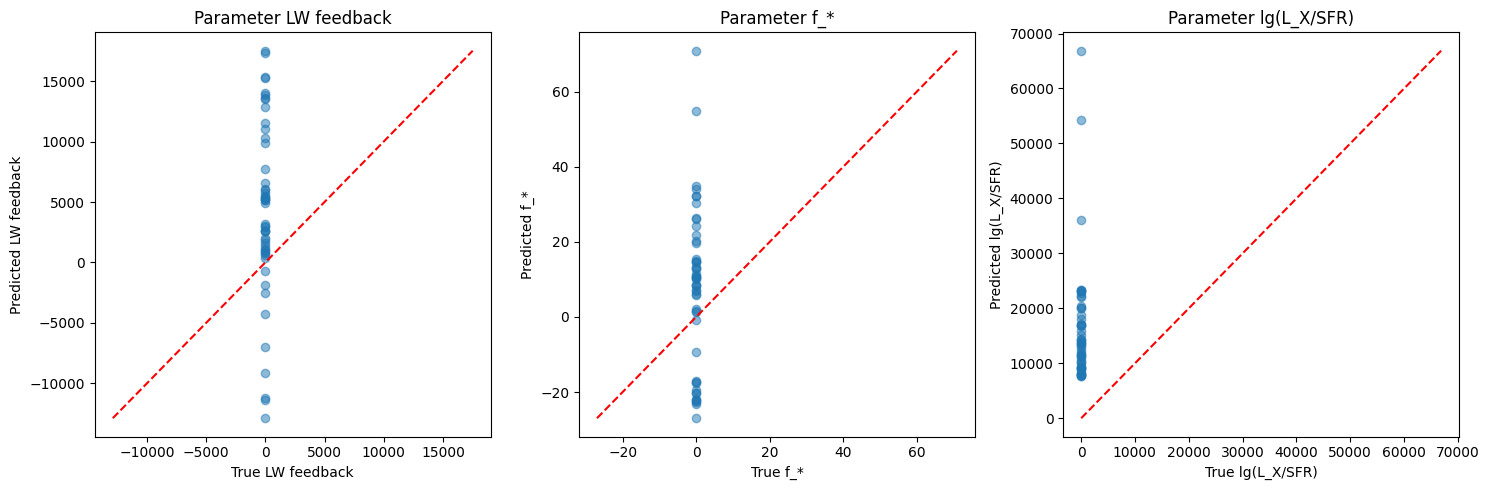

散点图已保存至 scatter_plot_bnn.png


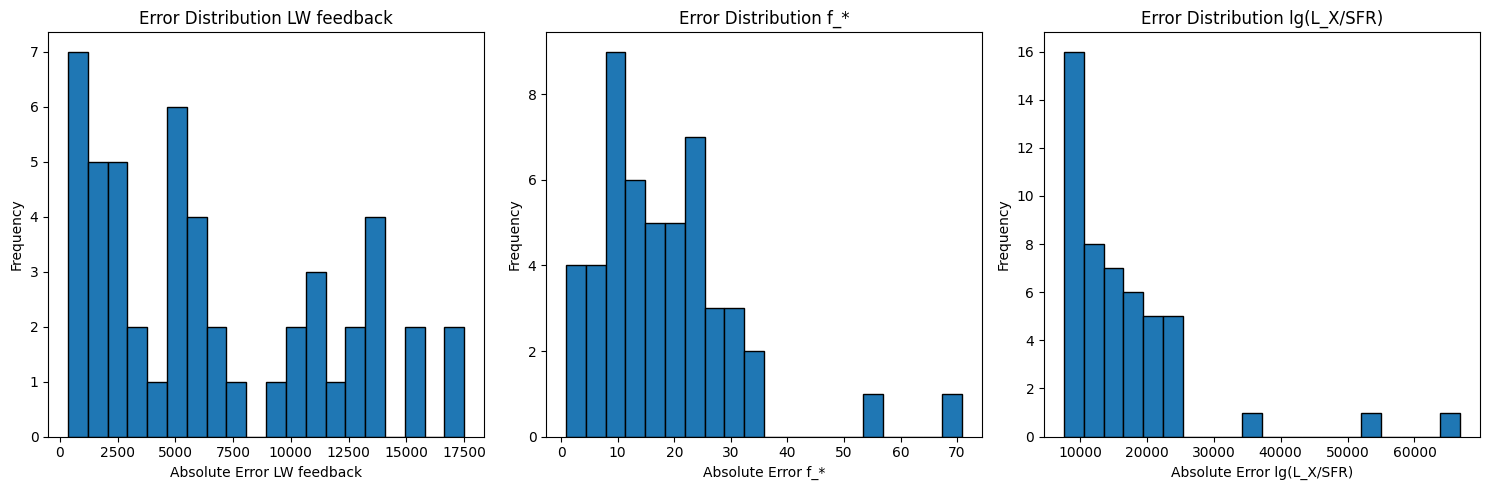

误差直方图已保存至 error_histogram_bnn.png


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib

def visualize_predictions(predictions, trues, table_path='predictions_table_bnn.csv', scatter_path='scatter_plot_bnn.png', hist_path='error_histogram_bnn.png'):
    # 加载归一化器
    scaler_a = joblib.load('tensorForTesting/processed/scaler_a.pkl')
    scaler_b = joblib.load('tensorForTesting/processed/scaler_b.pkl')
    scaler_c = joblib.load('tensorForTesting/processed/scaler_c.pkl')

    # 反归一化 predictions 和 trues
    predictions_denorm = np.zeros_like(predictions)
    trues_denorm = np.zeros_like(trues)
    predictions_denorm[:, 0] = scaler_a.inverse_transform(predictions[:, 0:1].reshape(-1, 1)).flatten()
    predictions_denorm[:, 1] = scaler_b.inverse_transform(predictions[:, 1:2].reshape(-1, 1)).flatten()
    predictions_denorm[:, 2] = scaler_c.inverse_transform(predictions[:, 2:3].reshape(-1, 1)).flatten()
    trues_denorm[:, 0] = scaler_a.inverse_transform(trues[:, 0:1].reshape(-1, 1)).flatten()
    trues_denorm[:, 1] = scaler_b.inverse_transform(trues[:, 1:2].reshape(-1, 1)).flatten()
    trues_denorm[:, 2] = scaler_c.inverse_transform(trues[:, 2:3].reshape(-1, 1)).flatten()

    # 表格：前 10 个样本的预测和真实值
    n_samples = min(10, len(predictions))
    df = pd.DataFrame({
        'Sample': range(n_samples),
        'True_LW feedback': trues_denorm[:n_samples, 0],
        'Pred_LW feedback': predictions_denorm[:n_samples, 0],
        'Error_LW feedback': np.abs(trues_denorm[:n_samples, 0] - predictions_denorm[:n_samples, 0]),
        'True_f_*': trues_denorm[:n_samples, 1],
        'Pred_f_*': predictions_denorm[:n_samples, 1],
        'Error_f_*': np.abs(trues_denorm[:n_samples, 1] - predictions_denorm[:n_samples, 1]),
        'True_lg(L_X/SFR)': trues_denorm[:n_samples, 2],
        'Pred_lg(L_X/SFR)': predictions_denorm[:n_samples, 2],
        'Error_lg(L_X/SFR)': np.abs(trues_denorm[:n_samples, 2] - predictions_denorm[:n_samples, 2])
    })
    print("测试集前 10 个样本的预测结果：")
    print(df.to_string(index=False))
    df.to_csv(table_path, index=False)
    print(f"表格已保存至 {table_path}")

    # 散点图：预测 vs. 真实值
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    labels = ['LW feedback', 'f_*', 'lg(L_X/SFR)']
    for i, ax in enumerate(axes):
        ax.scatter(trues_denorm[:, i], predictions_denorm[:, i], alpha=0.5)
        min_val = min(trues_denorm[:, i].min(), predictions_denorm[:, i].min())
        max_val = max(trues_denorm[:, i].max(), predictions_denorm[:, i].max())    
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')
        ax.set_xlabel(f'True {labels[i]}')
        ax.set_ylabel(f'Predicted {labels[i]}')
        ax.set_title(f'Parameter {labels[i]}')
    plt.tight_layout()
    plt.savefig(scatter_path)
    plt.show()
    print(f"散点图已保存至 {scatter_path}")

    # 误差分布直方图
    errors = np.abs(trues_denorm - predictions_denorm)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.hist(errors[:, i], bins=20, edgecolor='black')
        ax.set_xlabel(f'Absolute Error {labels[i]}')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Error Distribution {labels[i]}')
    plt.tight_layout()
    plt.savefig(hist_path)
    plt.show()
    print(f"误差直方图已保存至 {hist_path}")

# 加载数据（假设 load_data 函数与原代码一致）
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = BayesianCNN()
print(f"PyTorch parameters: {list(model.parameters())}")
print(f"Pyro parameters: {pyro.get_param_store().keys()}")

# 训练模型
model = train_bnn(model, train_loader, valid_loader, epochs=50)

# 测试模型
test_loss, test_mae, predictions, trues = test_bnn(model, test_loader)

# 可视化结果
visualize_predictions(predictions, trues)